# EDA and Randomization Balance Check

This notebook performs exploratory data analysis and checks whether the randomized experiment groups are balanced at baseline.

The goal is to verify that the `Standard Outreach` and `Diabetes Peer Support` groups are similar before comparing diabetes testing compliance outcomes.

Because this dataset is synthetic, results should be interpreted as a portfolio A/B testing exercise, not real clinical evidence.

## 1. Imports 

In [1]:
from pathlib import Path # Used for project-relative paths.

import numpy as np # Used for numerical operations.
import pandas as pd # Used for data loading and tabular analysis.
import matplotlib.pyplot as plt # Used for basic visualizations.

# Display settings for cleaner notebook output


This notebook performs descriptive balance checks only. Formal statistical testing is reserved for Notebook 2. 

## 2. Load Dataset

In [2]:
# Define project root
project_root = Path("..")

# Define data path
data_path = project_root / "data" / "raw" / "mock_diabetes_peer_support_ab_test.csv"

# Load dataset

df = pd.read_csv(data_path)

# Preview first five rows

df.head()





,member_id,age,gender,region,plan_type,target_population_flag,diabetes_severity_score,chronic_condition_count,baseline_engagement_score,health_literacy_score,...,peer_leader_supervised,contact_frequency_per_month,assigned_diabetes_tests_count,a1c_test_completed,kidney_screening_completed,eye_exam_completed,diabetes_tests_completed_count,diabetes_testing_compliance_rate,diabetes_testing_compliant,program_data_quality_issue
0,1,64,Male,Urban,Medicaid,1,0.263,1,0.866,0.349,...,0,1,3,1,1,1,3,1.000,1,0
1,2,69,Male,Rural,D-SNP,1,0.361,5,0.253,0.533,...,1,2,3,1,0,0,1,0.333,0,0
2,3,74,Female,Urban,Medicare Advantage,1,0.598,2,0.483,0.189,...,0,1,3,1,0,0,1,0.333,0,0
3,4,72,Male,Urban,Medicare Advantage,1,0.189,4,0.377,0.811,...,1,2,3,0,1,1,2,0.667,0,0
4,5,42,Female,Suburban,Medicaid,1,0.759,3,0.541,0.606,...,0,1,3,1,1,0,2,0.667,0,0


## 3. Basic Dataset Checks

In [3]:
# Check number of rows and columns
df.shape

(4000, 33)

In [4]:
# Check column names and data types
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 33 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   member_id                         4000 non-null   int64  
 1   age                               4000 non-null   int64  
 2   gender                            4000 non-null   str    
 3   region                            4000 non-null   str    
 4   plan_type                         4000 non-null   str    
 5   target_population_flag            4000 non-null   int64  
 6   diabetes_severity_score           4000 non-null   float64
 7   chronic_condition_count           4000 non-null   int64  
 8   baseline_engagement_score         3749 non-null   float64
 9   health_literacy_score             3706 non-null   float64
 10  prior_testing_compliance_rate     4000 non-null   float64
 11  sdoh_risk_score                   4000 non-null   float64
 12  food_insecurity  

Each row represents one targetable diabetic member assigned to either Standard Outreach or Diabetes Peer Support.

## 4. Missing Values Review

In [5]:
missing_counts = df.isna().sum()
missing_counts[missing_counts > 0].sort_values(ascending=False)

health_literacy_score        294
baseline_engagement_score    251
dtype: int64

The missing values in this dataset are intentional. The data-generation script creates structured missingness in `health_literacy_score` and `baseline_engagement_score` to simulate incomplete operational data capture.

These missing values should not be interpreted as a data-generation error.

Because missingness is structured, complete-case analysis could bias adjusted models if missingness is related to member risk. For randomization balance checks, I check whether missingness itself is balanced by experiment group.

## 5. Check Experiment Group Distribution

In [6]:
# Count members by experiment group

df["experiment_group"].value_counts()

experiment_group
Diabetes Peer Support    2078
Standard Outreach        1922
Name: count, dtype: int64

The groups are not exactly equal, but the difference is expected under simple random assignment and does not by itself indicate a randomization problem.

In [7]:
# Percentage distribution by experiment group

df["experiment_group"].value_counts(normalize=True).round(3)

experiment_group
Diabetes Peer Support    0.52
Standard Outreach        0.48
Name: proportion, dtype: float64

## 6. Target Population Check

In [8]:
df["target_population_flag"].value_counts()


target_population_flag
1    4000
Name: count, dtype: int64

This dataset does not represent the full health plan population. It represents the final targetable diabetic population: adult members with diabetes who have assigned diabetes tests.

## 7. Plan-Type and Age Sanity Check

In [9]:
df.groupby("plan_type")["age"].agg(["min", "mean", "max"]).round(1)

,min,mean,max
plan_type,,,
D-SNP,65,72.3,89
Medicaid,18,47.6,85
Medicare Advantage,65,72.8,89


For simplicity, Medicare Advantage and D-SNP members were simulated as age 65+, while Medicaid members include adults under 65.

## 8. Baseline Numeric and Binary Balance

In [10]:
baseline_numeric_cols = [
    "age",
    "diabetes_severity_score",
    "chronic_condition_count",
    "baseline_engagement_score",
    "health_literacy_score",
    "prior_testing_compliance_rate",
    "sdoh_risk_score"
]

df.groupby("experiment_group")[baseline_numeric_cols].mean().round(3)

,age,diabetes_severity_score,chronic_condition_count,baseline_engagement_score,health_literacy_score,prior_testing_compliance_rate,sdoh_risk_score
experiment_group,,,,,,,
Diabetes Peer Support,60.082,0.439,2.778,0.518,0.514,0.600,0.332
Standard Outreach,60.130,0.440,2.772,0.510,0.506,0.602,0.330


In [11]:
smd_vars = [
    "age",
    "diabetes_severity_score",
    "chronic_condition_count",
    "baseline_engagement_score",
    "health_literacy_score",
    "prior_testing_compliance_rate",
    "sdoh_risk_score",
    "food_insecurity",
    "transportation_barrier",
    "financial_barrier",
    "housing_instability",
    "pcp_attributed_24mo"
]

treatment_group = df[df["experiment_group"] == "Diabetes Peer Support"]
control_group = df[df["experiment_group"] == "Standard Outreach"]


def calculate_smd(treatment, control, variable):
    treatment_mean = treatment[variable].mean()
    control_mean = control[variable].mean()

    treatment_std = treatment[variable].std()
    control_std = control[variable].std()

    pooled_std = np.sqrt((treatment_std**2 + control_std**2) / 2)

    if pooled_std == 0:
        return np.nan

    return (treatment_mean - control_mean) / pooled_std


smd_results = []

for var in smd_vars:
    smd = calculate_smd(treatment_group, control_group, var)

    smd_results.append({
        "variable": var,
        "treatment_mean": treatment_group[var].mean(),
        "control_mean": control_group[var].mean(),
        "raw_difference": treatment_group[var].mean() - control_group[var].mean(),
        "smd": smd,
        "abs_smd": abs(smd),
        "balance_flag": "Potential imbalance" if abs(smd) >= 0.10 else "Acceptable"
    })

smd_table = pd.DataFrame(smd_results)

smd_table.sort_values("abs_smd", ascending=False).round(3)

,variable,treatment_mean,control_mean,raw_difference,smd,abs_smd,balance_flag
11,pcp_attributed_24mo,0.627,0.601,0.026,0.053,0.053,Acceptable
4,health_literacy_score,0.514,0.506,0.008,0.039,0.039,Acceptable
3,baseline_engagement_score,0.518,0.510,0.008,0.037,0.037,Acceptable
10,housing_instability,0.223,0.211,0.012,0.029,0.029,Acceptable
9,financial_barrier,0.386,0.394,-0.007,-0.015,0.015,Acceptable
8,transportation_barrier,0.297,0.291,0.007,0.014,0.014,Acceptable
7,food_insecurity,0.353,0.347,0.006,0.012,0.012,Acceptable
5,prior_testing_compliance_rate,0.600,0.602,-0.002,-0.012,0.012,Acceptable
6,sdoh_risk_score,0.332,0.330,0.002,0.008,0.008,Acceptable
1,diabetes_severity_score,0.439,0.440,-0.002,-0.008,0.008,Acceptable


### Interpretation

This table checks whether baseline numeric and binary member characteristics are balanced between the Diabetes Peer Support group and the Standard Outreach group.

The standardized mean difference compares group differences on a common scale.

A common rule of thumb is:

- `|SMD| < 0.10`: acceptable balance
- `|SMD| >= 0.10`: possible imbalance worth reviewing

All variables in this table are baseline or pre-treatment variables. Outcome variables and post-assignment funnel variables are excluded.

## 9. Categorical Balance Check

In [12]:
baseline_categorical_cols = [
    "gender",
    "region",
    "plan_type"
]

for col in baseline_categorical_cols:
    display(
        pd.crosstab(
            df[col],
            df["experiment_group"],
            normalize="columns"
        ).round(3)
    )

experiment_group,Diabetes Peer Support,Standard Outreach
gender,,
Female,0.541,0.524
Male,0.459,0.476


experiment_group,Diabetes Peer Support,Standard Outreach
region,,
Rural,0.213,0.201
Suburban,0.353,0.361
Urban,0.435,0.438


experiment_group,Diabetes Peer Support,Standard Outreach
plan_type,,
D-SNP,0.250,0.250
Medicaid,0.503,0.495
Medicare Advantage,0.247,0.255


In [13]:
# ------------------------------------------------------------
# Categorical Variable SMD Check
# ------------------------------------------------------------

categorical_vars = ["gender", "region", "plan_type"]

categorical_dummies = pd.get_dummies(
    df[categorical_vars],
    drop_first=False
)

categorical_balance_df = pd.concat(
    [df[["experiment_group"]], categorical_dummies],
    axis=1
)

treatment_cat = categorical_balance_df[
    categorical_balance_df["experiment_group"] == "Diabetes Peer Support"
]

control_cat = categorical_balance_df[
    categorical_balance_df["experiment_group"] == "Standard Outreach"
]

categorical_smd_results = []

for var in categorical_dummies.columns:
    treatment_mean = treatment_cat[var].mean()
    control_mean = control_cat[var].mean()

    treatment_std = treatment_cat[var].std()
    control_std = control_cat[var].std()

    pooled_std = np.sqrt((treatment_std**2 + control_std**2) / 2)

    smd = np.nan if pooled_std == 0 else (treatment_mean - control_mean) / pooled_std

    categorical_smd_results.append({
        "category": var,
        "treatment_proportion": treatment_mean,
        "control_proportion": control_mean,
        "raw_difference": treatment_mean - control_mean,
        "smd": smd,
        "abs_smd": abs(smd),
        "balance_flag": "Potential imbalance" if abs(smd) >= 0.10 else "Acceptable"
    })

categorical_smd_table = pd.DataFrame(categorical_smd_results)

categorical_smd_table.sort_values("abs_smd", ascending=False).round(3)

,category,treatment_proportion,control_proportion,raw_difference,smd,abs_smd,balance_flag
0,gender_Female,0.541,0.524,0.016,0.033,0.033,Acceptable
1,gender_Male,0.459,0.476,-0.016,-0.033,0.033,Acceptable
2,region_Rural,0.213,0.201,0.011,0.028,0.028,Acceptable
7,plan_type_Medicare Advantage,0.247,0.255,-0.008,-0.017,0.017,Acceptable
3,region_Suburban,0.353,0.361,-0.008,-0.017,0.017,Acceptable
6,plan_type_Medicaid,0.503,0.495,0.008,0.015,0.015,Acceptable
4,region_Urban,0.435,0.438,-0.003,-0.006,0.006,Acceptable
5,plan_type_D-SNP,0.250,0.250,0.000,0.000,0.000,Acceptable


### Interpretation

Missingness appears reasonably balanced between the Diabetes Peer Support and Standard Outreach groups based on standardized mean differences.

However, balanced missingness does not guarantee that missing data are harmless. The synthetic data intentionally includes structured missingness, meaning missing values may be related to member risk, engagement, or access barriers.

For example, the health literacy missing rate is slightly higher in the Diabetes Peer Support group than in the Standard Outreach group. Even though the absolute SMD is below the common 0.10 threshold, differential missingness can still affect adjusted regression modeling if the missing variable is related to the outcome.

In the formal A/B testing and adjusted sensitivity analysis notebooks, missingness should be monitored carefully. Possible approaches include missingness indicator variables, imputation, or sensitivity checks comparing complete-case and missingness-adjusted models.

## 10. Missingness Balance Check

In [14]:
# ------------------------------------------------------------
# Missingness Balance Check
# ------------------------------------------------------------

missingness_vars = [
    "baseline_engagement_score",
    "health_literacy_score"
]

missingness_df = df[["experiment_group"]].copy()

for col in missingness_vars:
    missingness_df[f"{col}_missing"] = df[col].isna().astype(int)

missingness_rate_table = missingness_df.groupby("experiment_group").mean().T

missingness_rate_table.round(3)

experiment_group,Diabetes Peer Support,Standard Outreach
baseline_engagement_score_missing,0.063,0.063
health_literacy_score_missing,0.080,0.067


In [15]:
# ------------------------------------------------------------
# Missingness SMD Check
# ------------------------------------------------------------

treatment_missing = missingness_df[
    missingness_df["experiment_group"] == "Diabetes Peer Support"
]

control_missing = missingness_df[
    missingness_df["experiment_group"] == "Standard Outreach"
]

missing_smd_results = []

for var in [f"{col}_missing" for col in missingness_vars]:
    treatment_mean = treatment_missing[var].mean()
    control_mean = control_missing[var].mean()

    treatment_std = treatment_missing[var].std()
    control_std = control_missing[var].std()

    pooled_std = np.sqrt((treatment_std**2 + control_std**2) / 2)

    smd = np.nan if pooled_std == 0 else (treatment_mean - control_mean) / pooled_std

    missing_smd_results.append({
        "missingness_variable": var,
        "treatment_missing_rate": treatment_mean,
        "control_missing_rate": control_mean,
        "raw_difference": treatment_mean - control_mean,
        "smd": smd,
        "abs_smd": abs(smd),
        "balance_flag": "Potential imbalance" if abs(smd) >= 0.10 else "Acceptable"
    })

missing_smd_table = pd.DataFrame(missing_smd_results)

missing_smd_table.sort_values("abs_smd", ascending=False).round(3)

,missingness_variable,treatment_missing_rate,control_missing_rate,raw_difference,smd,abs_smd,balance_flag
1,health_literacy_score_missing,0.080,0.067,0.013,0.051,0.051,Acceptable
0,baseline_engagement_score_missing,0.063,0.063,-0.000,-0.002,0.002,Acceptable


### Interpretation

This section checks whether missingness is balanced between the treatment and control groups.

This matters because missing values are intentionally structured in the synthetic data. If missingness were highly imbalanced by experiment group, later adjusted analysis could become harder to interpret.

The missingness indicators are checked separately from the original variables because missingness itself can be an important data quality pattern.

## 11. SDOH Barrier Balance Check

In [16]:
# ------------------------------------------------------------
# SDOH Barrier Balance Highlight
# ------------------------------------------------------------
# Purpose:
# Highlight SDOH-specific balance results from the main SMD table.

sdoh_vars = [
    "food_insecurity",
    "transportation_barrier",
    "financial_barrier",
    "housing_instability",
    "sdoh_risk_score"
]

sdoh_balance_table = smd_table[
    smd_table["variable"].isin(sdoh_vars)
].sort_values("abs_smd", ascending=False)

sdoh_balance_table.round(3)

,variable,treatment_mean,control_mean,raw_difference,smd,abs_smd,balance_flag
10,housing_instability,0.223,0.211,0.012,0.029,0.029,Acceptable
9,financial_barrier,0.386,0.394,-0.007,-0.015,0.015,Acceptable
8,transportation_barrier,0.297,0.291,0.007,0.014,0.014,Acceptable
7,food_insecurity,0.353,0.347,0.006,0.012,0.012,Acceptable
6,sdoh_risk_score,0.332,0.330,0.002,0.008,0.008,Acceptable


### Interpretation

This section highlights SDOH-related balance results from the main standardized mean difference table.

The SDOH variables are important for healthcare outreach because social barriers may affect a member's ability to complete diabetes testing.

These variables were not recalculated here. Instead, they were filtered from the main baseline SMD table to avoid redundant code.

If all SDOH-related absolute SMD values are below 0.10, the treatment and control groups appear reasonably balanced on observed social-risk factors.

## 12. Create SDOH Risk Group in Notebook

In [17]:
# ------------------------------------------------------------
# Check whether SDOH risk score supports quantile splitting
# ------------------------------------------------------------

sdoh_unique_count = df["sdoh_risk_score"].nunique()
sdoh_total_count = df["sdoh_risk_score"].count()

print(f"Unique SDOH risk score values: {sdoh_unique_count}")
print(f"Total non-missing SDOH risk score values: {sdoh_total_count}")
print(f"Unique value ratio: {sdoh_unique_count / sdoh_total_count:.3f}")

Unique SDOH risk score values: 855
Total non-missing SDOH risk score values: 4000
Unique value ratio: 0.214


In [18]:
# Create tertile-based SDOH risk groups safely
df["sdoh_risk_group"] = pd.qcut(
    df["sdoh_risk_score"],
    q=3,
    labels=False,
    duplicates="drop"
)

# Map numeric groups to readable labels
sdoh_group_labels = {
    0: "Low",
    1: "Medium",
    2: "High"
}

df["sdoh_risk_group"] = df["sdoh_risk_group"].map(sdoh_group_labels)

df["sdoh_risk_group"].value_counts()

sdoh_risk_group
Low       1340
High      1331
Medium    1329
Name: count, dtype: int64

### Interpretation

The SDOH risk group is created by splitting the continuous `sdoh_risk_score` into three quantile-based groups: Low, Medium, and High.

Before using `pd.qcut`, I checked the number of unique SDOH risk score values. This matters because heavy ties can make quantile-based splitting unstable or cause `qcut` to fail.

In this dataset, the SDOH risk score has enough unique values to support a clean tertile split. The resulting groups are used for exploratory segmentation, not as pre-defined clinical risk categories.

## 13. PCP and Prior Compliance Balance

In [19]:
baseline_across_cols = [
    "pcp_attributed_24mo",
    "prior_testing_compliance_rate"
]

df.groupby("experiment_group")[baseline_across_cols].mean().round(3)

,pcp_attributed_24mo,prior_testing_compliance_rate
experiment_group,,
Diabetes Peer Support,0.627,0.600
Standard Outreach,0.601,0.602


## 14. Visual Baseline Balance

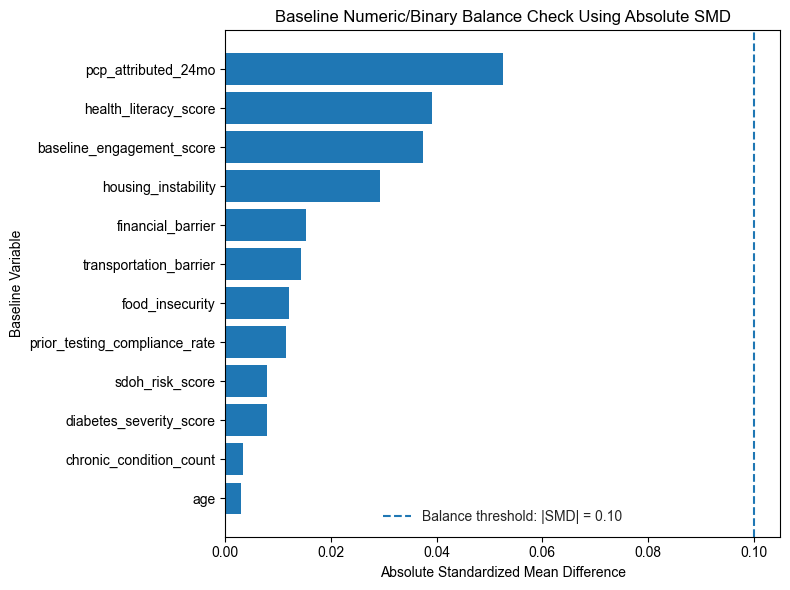

In [20]:
# ------------------------------------------------------------
# SMD Love Plot
# ------------------------------------------------------------

smd_plot_data = smd_table.sort_values("abs_smd", ascending=True)

plt.figure(figsize=(8, 6))

plt.barh(
    smd_plot_data["variable"],
    smd_plot_data["abs_smd"]
)

plt.axvline(
    x=0.10,
    linestyle="--",
    label="Balance threshold: |SMD| = 0.10"
)

plt.xlabel("Absolute Standardized Mean Difference")
plt.ylabel("Baseline Variable")
plt.title("Baseline Numeric/Binary Balance Check Using Absolute SMD")
plt.style.use('seaborn-v0_8-whitegrid')
plt.legend()
plt.tight_layout()
plt.show()

### Interpretation

This plot summarizes baseline balance using absolute standardized mean differences.

Variables closer to zero are more balanced between the two experiment groups. The dashed vertical line marks the common 0.10 threshold for potential imbalance.

This visualization is stronger than comparing raw means alone because all variables are placed on the same standardized scale.

## 15. Peer-Support Funnel Structural Check

In [21]:
peer_cols = [
    "program_invited",
    "program_enrolled",
    "attended_at_least_one_session",
    "sessions_attended_count",
    "peer_leader_supervised",
    "contact_frequency_per_month"
]

df.groupby("experiment_group")[peer_cols].mean().round(3)

,program_invited,program_enrolled,attended_at_least_one_session,sessions_attended_count,peer_leader_supervised,contact_frequency_per_month
experiment_group,,,,,,
Diabetes Peer Support,0.846,0.368,0.135,0.493,1.0,2.0
Standard Outreach,0.000,0.000,0.000,0.000,0.0,1.0


Enrollment and attendance are downstream of treatment assignment, so they should not be used as baseline balance variables or as adjustment variables in the primary ITT estimate.

In [22]:
funnel_violations = (
    ((df["experiment_group"] == "Standard Outreach") & (df["program_invited"] == 1)).sum()
    + ((df["program_invited"] == 0) & (df["program_enrolled"] == 1)).sum()
    + ((df["program_enrolled"] == 0) & (df["attended_at_least_one_session"] == 1)).sum()
    + ((df["attended_at_least_one_session"] == 0) & (df["sessions_attended_count"] > 0)).sum()
)

funnel_violations

np.int64(0)

I validated funnel logic to ensure no control members were marked as invited and no members appeared in later funnel stages without passing earlier stages

## 16. Treatment Funnel Rates

In [23]:
treatment_df = df[df["experiment_group"] == "Diabetes Peer Support"]

funnel_summary = {
    "invitation_rate": treatment_df["program_invited"].mean(),
    "enrollment_rate_among_invited": treatment_df.loc[
        treatment_df["program_invited"] == 1,
        "program_enrolled"
    ].mean(),
    "attendance_rate_among_enrolled": treatment_df.loc[
        treatment_df["program_enrolled"] == 1,
        "attended_at_least_one_session"
    ].mean(),
    "average_sessions_attended": treatment_df["sessions_attended_count"].mean()
}

pd.Series(funnel_summary).round(3)

invitation_rate                   0.846
enrollment_rate_among_invited     0.435
attendance_rate_among_enrolled    0.366
average_sessions_attended         0.493
dtype: float64

| Metric | Denominator |
| :--- | :--- |
| **Invitation rate** | All treatment-assigned members |
| **Enrollment rate among invited** | Invited treatment members |
| **Attendance rate among enrolled** | Enrolled treatment members |
| **Average sessions attended** | All treatment-assigned members |

## 17. Diabetes Test Logic Check

In [24]:
testing_cols = [
    "assigned_diabetes_tests_count",
    "a1c_test_completed",
    "kidney_screening_completed",
    "eye_exam_completed",
    "diabetes_tests_completed_count",
    "diabetes_testing_compliance_rate",
    "diabetes_testing_compliant"
]

df[testing_cols].describe().round(3)

,assigned_diabetes_tests_count,a1c_test_completed,kidney_screening_completed,eye_exam_completed,diabetes_tests_completed_count,diabetes_testing_compliance_rate,diabetes_testing_compliant
count,4000.0,4000.000,4000.000,4000.000,4000.000,4000.000,4000.00
mean,3.0,0.821,0.730,0.636,2.187,0.729,0.40
std,0.0,0.383,0.444,0.481,0.795,0.265,0.49
min,3.0,0.000,0.000,0.000,0.000,0.000,0.00
25%,3.0,1.000,0.000,0.000,2.000,0.667,0.00
50%,3.0,1.000,1.000,1.000,2.000,0.667,0.00
75%,3.0,1.000,1.000,1.000,3.000,1.000,1.00
max,3.0,1.000,1.000,1.000,3.000,1.000,1.00


Because each member has 3 assigned tests, the 75% threshold classifies only members completing all 3 tests as compliant.

In [25]:
test_count_check = (
    df["diabetes_tests_completed_count"]
    == df["a1c_test_completed"] + df["kidney_screening_completed"] + df["eye_exam_completed"]
)

test_count_check.mean()

np.float64(1.0)

In [26]:
df["diabetes_testing_compliance_rate"].between(0, 1).mean()

np.float64(1.0)

## 18. Diabetes Test Difficulty Hierarchy

In [27]:
df[
    [
        "a1c_test_completed",
        "kidney_screening_completed",
        "eye_exam_completed"
    ]
].mean().sort_values(ascending=False).round(3)

a1c_test_completed            0.821
kidney_screening_completed    0.730
eye_exam_completed            0.636
dtype: float64

## 19. Quick Outcome Preview

In [28]:
df.groupby("experiment_group")[
    [
        "a1c_test_completed",
        "kidney_screening_completed",
        "eye_exam_completed",
        "diabetes_testing_compliance_rate",
        "diabetes_testing_compliant"
    ]
].mean().round(3)

,a1c_test_completed,kidney_screening_completed,eye_exam_completed,diabetes_testing_compliance_rate,diabetes_testing_compliant
experiment_group,,,,,
Diabetes Peer Support,0.832,0.742,0.66,0.745,0.423
Standard Outreach,0.809,0.718,0.61,0.713,0.376


These are descriptive outcome differences only. Formal hypothesis testing and confidence intervals are handled in the next notebook.

## 20. Findings

This notebook verified that the synthetic Diabetes Peer Support A/B testing dataset is structurally ready for formal treatment-effect analysis.

Key findings:

- The dataset contains 4,000 targetable diabetic members and each row represents one member in the outreach experiment.
- The experiment groups are reasonably split between Standard Outreach and Diabetes Peer Support, consistent with simple random assignment.
- All members are part of the intended target population, so the analysis is limited to diabetic members eligible for diabetes testing outreach.
- Baseline numeric and binary characteristics are well balanced between treatment and control groups.
- All observed standardized mean differences were below the common 0.10 imbalance threshold, suggesting acceptable baseline balance.
- Categorical baseline variables such as gender, region, and plan type also appear reasonably balanced after converting categories into dummy variables.
- Missingness exists in baseline engagement and health literacy, but missingness rates appear reasonably balanced between experiment groups.
- SDOH barrier variables are balanced enough for the dataset to proceed to formal A/B testing.
- Peer-support funnel logic is structurally valid: control members were not invited, and no members skipped impossible funnel stages.
- Diabetes testing outcome variables are internally consistent: completed test counts match the component test flags, and compliance rates fall between 0 and 1.
- The diabetes test difficulty pattern follows the intended synthetic design, with A1c completion highest and eye exam completion lowest.
- Outcome differences are shown only as an exploratory preview. They should not be interpreted as final treatment effects until formal statistical testing is completed.

Conclusion:

The dataset passes the main EDA, randomization balance, missingness, and funnel-validity checks needed before formal A/B testing. The next notebook should estimate the treatment effect using an intent-to-treat framework, including absolute lift, relative lift, confidence intervals, p-values, and practical significance.

#### Important limitation:

Because this is synthetic data, the results demonstrate A/B testing methodology and healthcare outreach interpretation. They should not be interpreted as real-world clinical evidence.